# 01 · Exploración del dataset de siniestros
**Reto Aseguradora del Sur — Detector de posibles fraudes**

Este notebook carga el CSV sintético (`siniestros_sintetico.csv`), valida su estructura
y explora las señales de fraude de las secciones 7–8 del documento.

> ⚠️ El resultado del modelo es una **alerta de revisión**, no una acusación de fraude.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Importaciones

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (9, 4)

## 2. Carga del dataset
El archivo está en **UTF-8 con BOM** (para que las tildes se vean bien en Excel);
`utf-8-sig` lo lee sin problema. El loader prueba varias rutas comunes.

In [ ]:
from pathlib import Path

CANDIDATOS = [
    "siniestros_merged.csv",
    "/data/processed/siniestros_merged.csv",
    "../data/processed/siniestros_merged.csv",
]
ruta = next((p for p in CANDIDATOS if Path(p).exists()), None)
assert ruta, "No encontré el CSV. Sube 'siniestros_sintetico.csv' o ajusta la ruta."

# Forzamos los IDs a texto para no perder ceros a la izquierda
df = pd.read_csv(
    ruta,
    encoding="utf-8-sig",
    dtype={"id_siniestro": str, "id_poliza": str, "id_asegurado": str,
           "id_proveedor": str, "id_conductor": str},
    parse_dates=["fecha_ocurrencia", "fecha_reporte",
                 "fecha_inicio_poliza", "fecha_fin_poliza"],
)
print(f"Cargado: {ruta}")
print(f"Filas: {len(df):,}  |  Columnas: {df.shape[1]}")
df.head()

Cargado: /content/drive/MyDrive/hackIAthon/siniestros_sintetico.csv
Filas: 1,000  |  Columnas: 51


,id_siniestro,id_poliza,id_asegurado,ramo,cobertura,fecha_ocurrencia,fecha_reporte,monto_reclamado,monto_estimado,monto_pagado,estado,sucursal,descripcion,documentos_completos,beneficiario,dias_desde_inicio_poliza,dias_desde_fin_poliza,dias_entre_ocurrencia_reporte,historial_siniestros_asegurado,etiqueta_fraude_simulada,ciudad,canal_venta,fecha_inicio_poliza,fecha_fin_poliza,prima,suma_asegurada,deducible,ratio_monto_suma_asegurada,segmento_asegurado,antiguedad_asegurado_meses,score_cliente_simulado,placa,chasis,motor,marca,modelo,anio_vehiculo,id_conductor,tipo_accidente,tercero_identificado,dano_severo,id_proveedor,tipo_proveedor,proveedor_en_lista_restrictiva,horas_hasta_denuncia_robo,documento_inconsistente,factura_fecha_previa_evento,frecuencia_vehiculo_18m,frecuencia_conductor_18m,casos_observados_proveedor,reclamos_ultimos_12m
0,SIN-000001,POL-000332,ASG-00375,Vehículos,Choque,2024-07-03,2024-07-16,8318.63,7768.02,5099.01,Pago Parcial,Sucursal Guayaquil,El vehículo asegurado vuelca tras perder el co...,No,Clínica,122,243,13,2,1,Guayaquil,Bancaseguros,2024-03-03,2025-03-03,1737.12,25000.0,0.0,0.333,Masivo,7,475,BGH-1717,8JX291JHGBJKZ9ASD,Y4A47VV8,Nissan,Frontier,2024.0,COND-00128,Lateral,0.0,0.0,PRV-0015,Clínica,0,NaN,0,0,1,5,1,2
1,SIN-000002,POL-000303,ASG-00421,Salud,Hospitalización,2023-11-01,2023-11-18,15672.21,13244.04,11762.00,Pago Total,Agencia Loja,Ingreso hospitalario del asegurado por una eme...,No,Concesionario,17,348,17,4,0,Loja,Oficina,2023-10-15,2024-10-14,1268.77,18000.0,1800.0,0.871,Corporativo,111,668,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PRV-0008,Concesionario,0,NaN,0,0,0,0,6,4
2,SIN-000003,POL-000250,ASG-00364,Salud,Hospitalización,2024-10-24,2024-11-04,3361.08,2800.85,2681.79,Pago Total,Agencia Loja,Ingreso hospitalario del asegurado tras un mal...,No,Taller,291,74,11,0,1,Guayaquil,Agente,2024-01-07,2025-01-06,444.64,12000.0,0.0,0.280,PyME,78,693,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PRV-0002,Taller,0,NaN,0,1,0,0,13,0
3,SIN-000004,POL-X000602,ASG-00005,Vehículos,Responsabilidad Civil,2024-03-19,2024-03-19,4795.17,4785.02,0.00,Cierre Sin Consecuencia,Sucursal Guayaquil,El asegurado ocasiona daños a un tercero en un...,Sí,Clínica,246,119,0,5,0,Guayaquil,Digital,2023-07-17,2024-07-16,955.82,12000.0,600.0,0.400,Corporativo,115,577,BDJ-1206,8F95D6J936D6WB2TA,PEC4ZEDE,Renault,Logan,2024.0,COND-00211,Posterior,1.0,0.0,PRV-0021,Clínica,0,NaN,0,0,2,3,0,5
4,SIN-000005,POL-000148,ASG-00144,Hogar,Incendio,2025-02-26,2025-03-01,4147.88,2968.94,0.00,Reserva,Sucursal Cuenca,Incendio que afecta el inmueble asegurado un f...,Sí,Centro médico,230,135,3,0,1,Guayaquil,Agente,2024-07-11,2025-07-11,371.86,8000.0,400.0,0.518,Corporativo,34,739,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PRV-0025,Centro médico,0,NaN,0,0,0,0,0,0


## 3. Estructura y tipos de datos

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 51 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id_siniestro                    1000 non-null   object        
 1   id_poliza                       1000 non-null   object        
 2   id_asegurado                    1000 non-null   object        
 3   ramo                            1000 non-null   object        
 4   cobertura                       1000 non-null   object        
 5   fecha_ocurrencia                1000 non-null   datetime64[ns]
 6   fecha_reporte                   1000 non-null   datetime64[ns]
 7   monto_reclamado                 1000 non-null   float64       
 8   monto_estimado                  1000 non-null   float64       
 9   monto_pagado                    1000 non-null   float64       
 10  estado                          1000 non-null   object        
 11  sucur

In [17]:
df.tail(25)

,id_siniestro,id_poliza,id_asegurado,ramo,cobertura,fecha_ocurrencia,fecha_reporte,monto_reclamado,monto_estimado,monto_pagado,estado,sucursal,descripcion,documentos_completos,beneficiario,dias_desde_inicio_poliza,dias_desde_fin_poliza,dias_entre_ocurrencia_reporte,historial_siniestros_asegurado,etiqueta_fraude_simulada,ciudad,canal_venta,fecha_inicio_poliza,fecha_fin_poliza,prima,suma_asegurada,deducible,ratio_monto_suma_asegurada,segmento_asegurado,antiguedad_asegurado_meses,score_cliente_simulado,placa,chasis,motor,marca,modelo,anio_vehiculo,id_conductor,tipo_accidente,tercero_identificado,dano_severo,id_proveedor,tipo_proveedor,proveedor_en_lista_restrictiva,horas_hasta_denuncia_robo,documento_inconsistente,factura_fecha_previa_evento,frecuencia_vehiculo_18m,frecuencia_conductor_18m,casos_observados_proveedor,reclamos_ultimos_12m
975,SIN-000976,POL-000509,ASG-00349,Vehículos,Choque,2023-06-30,2023-07-01,792.35,578.93,546.82,Liquidado,Agencia Loja,El vehículo asegurado vuelca tras perder el co...,Sí,Perito,58,307,1,8,0,Machala,Oficina,2023-05-03,2024-05-02,328.54,8000.0,0.0,0.099,Masivo,151,690,PGE-1262,0JY765ZW8GMFUJNTE,EB9B2PCT,Toyota,Fortuner,2021.0,COND-00314,Posterior,1.0,0.0,PRV-0035,Perito,0,NaN,0,0,2,2,0,8
976,SIN-000977,POL-000567,ASG-00464,Vehículos,Robo,2024-10-01,2024-10-03,6887.22,6553.50,6115.90,Pago Total,Sucursal Manta,El asegurado reporta el robo del vehículo en u...,Sí,Concesionario,122,243,2,2,0,Guayaquil,Digital,2024-06-01,2025-06-01,2167.54,25000.0,0.0,0.275,Corporativo,7,548,MDI-8576,9LKGGWY58ZT8T06AZ,WY7HUBK3,Chevrolet,Sail,2017.0,COND-00343,NaN,0.0,0.0,PRV-0018,Concesionario,0,65.0,0,0,3,1,1,2
977,SIN-000978,POL-000456,ASG-00361,Vehículos,Pérdida Total,2024-01-13,2024-01-15,2190.01,1856.92,0.00,Negativa,Sucursal Manta,El vehículo sufre daños severos en la autopist...,Sí,Perito,255,110,2,2,0,Quito,Bróker,2023-05-03,2024-05-02,683.66,8000.0,0.0,0.274,Preferente,117,644,PEH-8668,F021L75494K7B14FW,KMT16W6V,Renault,Logan,2011.0,COND-00295,Múltiple,1.0,1.0,PRV-0032,Perito,0,NaN,0,0,3,3,1,2
978,SIN-000979,POL-000361,ASG-00281,Vehículos,Choque,2024-07-18,2024-07-20,708.48,539.92,488.78,Pago Total,Matriz Quito,El vehículo asegurado colisiona lateralmente c...,Sí,Taller,296,69,2,5,0,Cuenca,Bancaseguros,2023-09-26,2024-09-25,583.70,8000.0,0.0,0.089,PyME,90,560,GGD-1666,02CKKST4WPU3A331U,N8TA2C5J,Mazda,Mazda3,2022.0,COND-00186,Frontal,1.0,0.0,PRV-0014,Taller,0,NaN,0,0,5,5,1,5
979,SIN-000980,POL-X000650,ASG-00180,Hogar,Incendio,2024-05-23,2024-05-24,8507.51,7753.52,7686.82,Liquidado,Sucursal Ambato,Incendio que afecta el inmueble asegurado dura...,Sí,Centro médico,326,39,1,0,1,Loja,Oficina,2023-07-02,2024-07-01,1904.62,25000.0,1250.0,0.340,PyME,58,693,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PRV-0023,Centro médico,0,NaN,0,0,0,0,1,0
980,SIN-000981,POL-000553,ASG-00438,Vehículos,Robo,2025-02-10,2025-02-15,25820.85,19040.33,0.00,Reserva,Matriz Quito,El asegurado reporta el robo del vehículo en u...,Sí,Clínica,151,214,5,3,1,Quito,Bróker,2024-09-12,2025-09-12,1180.83,25000.0,2500.0,1.033,Corporativo,60,703,GGI-3385,2FZRPYY0VP7AHZ5SS,CX1H1TVB,Kia,Picanto,2017.0,COND-00010,NaN,1.0,1.0,PRV-0005,Clínica,1,123.0,0,0,2,2,13,3
981,SIN-000982,POL-000274,ASG-00463,Vehículos,Pérdida Total,2023-09-07,2023-09-07,3897.25,2996.19,0.00,Reserva,Sucursal Manta,El vehículo sufre daños severos en una interse...,Sí,Concesionario,126,239,0,2,0,Quito,Digital,2023-05-04,2024-05-03,289.77,8000.0,0.0,0.487,Masivo,107,659,LBG-3838,TMS2FBPL12VKHW84W,JZG09N85,Kia,Sportage,2024.0,COND-00139,Volcadura,1.0,1.0,PRV-0017,Concesionario,0,NaN,0,0,4,3,1,2
982,SIN-000983,POL-000452,ASG-00407,Vehículos,Responsabilidad Civil,2024-10-22,2024-10-24,1044.61,977.26,938.83,Pago Total,Sucursal Guayaquil,El asegurado ocasiona daños a un tercero en un...,No,Clínica,39,326,2,5,0,Quito,Bancaseguros,2024-09-13,2025-09-13,528.44,8000.0,400.0,0.131,Preferente,17,555,TGB-8554,ZP5W6THFLWCPXKFSZ,29DWTMB2,Renault,Logan,2010.0,COND-00144,Posterior,1.0,0.0,PRV-0034,Clínica,0,

## 4. Validación de columnas clave
El CSV procesado debe traer columnas que **provienen de otras tablas** vía las referencias:
- `suma_asegurada` → de la tabla **Pólizas**
- `casos_observados_proveedor` → de la tabla **Proveedores**

In [8]:
cols_61 = ["id_siniestro","id_poliza","id_asegurado","ramo","cobertura","fecha_ocurrencia",
           "fecha_reporte","monto_reclamado","monto_estimado","monto_pagado","estado","sucursal",
           "descripcion","documentos_completos","beneficiario","dias_desde_inicio_poliza",
           "dias_desde_fin_poliza","dias_entre_ocurrencia_reporte","historial_siniestros_asegurado",
           "etiqueta_fraude_simulada"]
referencias = ["suma_asegurada", "casos_observados_proveedor", "prima", "deducible",
               "proveedor_en_lista_restrictiva"]

print("Campos sección 6.1 presentes:", all(c in df.columns for c in cols_61))
print("Referencias cruzadas presentes:")
for c in referencias:
    print(f"  - {c}: {'OK' if c in df.columns else 'FALTA'}")

Campos sección 6.1 presentes: True
Referencias cruzadas presentes:
  - suma_asegurada: OK
  - casos_observados_proveedor: OK
  - prima: OK
  - deducible: OK
  - proveedor_en_lista_restrictiva: OK


## 5. Valores faltantes
Hay nulos **estructurales esperados**: las columnas de vehículo (placa, chasis, motor, etc.)
están vacías en ramos no vehiculares, y `horas_hasta_denuncia_robo` solo aplica a cobertura Robo.
No son errores.

In [9]:
na = df.isna().sum()
na = na[na > 0].sort_values(ascending=False)
print("Columnas con nulos:")
print(na.to_string() if len(na) else "  ninguno")

Columnas con nulos:
horas_hasta_denuncia_robo    843
tipo_accidente               505
placa                        399
motor                        399
chasis                       399
marca                        399
modelo                       399
id_conductor                 399
anio_vehiculo                399
tercero_identificado         399
dano_severo                  399


## 6. La variable objetivo: prevalencia de fraude

No fraude (0): 856
Fraude   (1): 144
Prevalencia: 14.4%


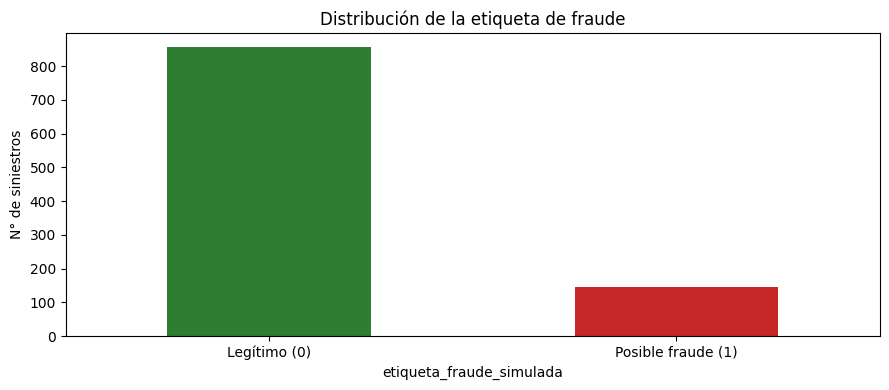

In [10]:
vc = df["etiqueta_fraude_simulada"].value_counts()
prev = df["etiqueta_fraude_simulada"].mean()
print(f"No fraude (0): {vc.get(0,0):,}")
print(f"Fraude   (1): {vc.get(1,0):,}")
print(f"Prevalencia: {prev:.1%}")

vc.sort_index().plot(kind="bar", color=["#2e7d32", "#c62828"])
plt.title("Distribución de la etiqueta de fraude")
plt.xticks([0,1], ["Legítimo (0)", "Posible fraude (1)"], rotation=0)
plt.ylabel("N° de siniestros"); plt.tight_layout(); plt.show()

## 7. Distribución por ramo y cobertura

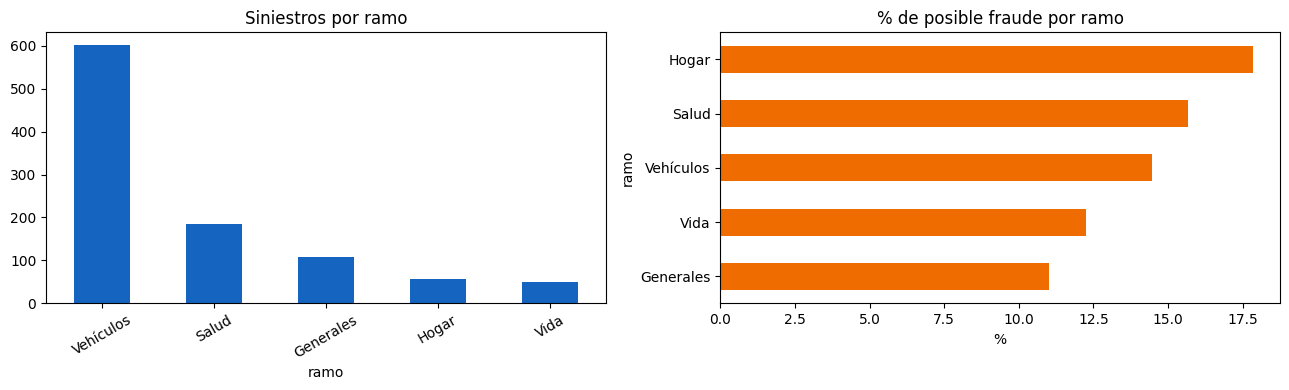

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
df["ramo"].value_counts().plot(kind="bar", ax=ax[0], color="#1565c0")
ax[0].set_title("Siniestros por ramo"); ax[0].tick_params(axis="x", rotation=30)

# % de fraude por ramo
(df.groupby("ramo")["etiqueta_fraude_simulada"].mean()*100).sort_values()\
    .plot(kind="barh", ax=ax[1], color="#ef6c00")
ax[1].set_title("% de posible fraude por ramo"); ax[1].set_xlabel("%")
plt.tight_layout(); plt.show()

## 8. Montos y relación con la suma asegurada

       monto_reclamado  monto_estimado  monto_pagado  suma_asegurada  ratio_monto_suma_asegurada
count           1000.0          1000.0        1000.0          1000.0                      1000.0
mean           10044.2          8579.7        4202.1         28059.0                         0.4
std            14409.1         12731.9        8969.9         31017.3                         0.2
min              414.9           336.3           0.0          8000.0                         0.1
25%             2899.6          2371.6           0.0         12000.0                         0.2
50%             5533.4          4748.8        1541.1         18000.0                         0.3
75%            11770.7          9930.2        4644.3         25000.0                         0.5
max           154363.4        142309.5      128316.9        150000.0                         1.1


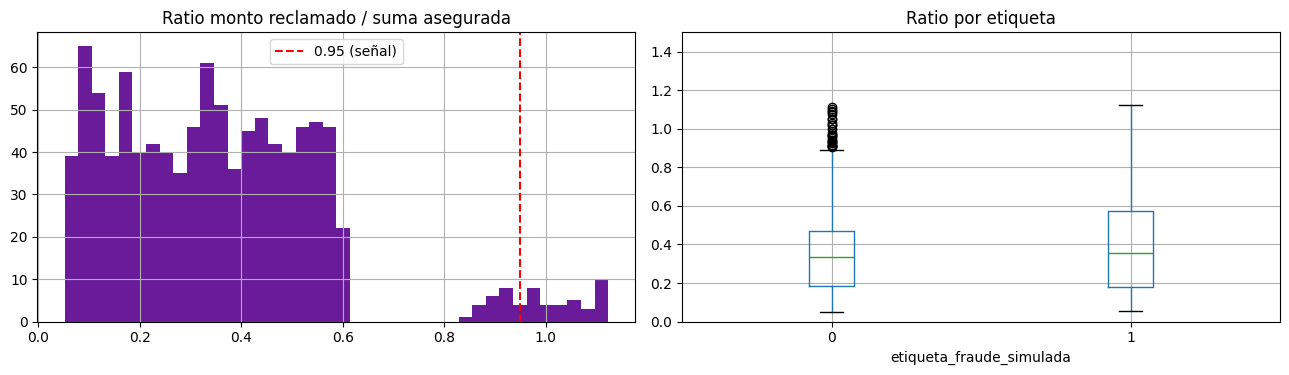

In [12]:
print(df[["monto_reclamado","monto_estimado","monto_pagado",
          "suma_asegurada","ratio_monto_suma_asegurada"]].describe().round(1))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
df["ratio_monto_suma_asegurada"].clip(0, 2).hist(bins=40, ax=ax[0], color="#6a1b9a")
ax[0].axvline(0.95, color="red", ls="--", label="0.95 (señal)")
ax[0].set_title("Ratio monto reclamado / suma asegurada"); ax[0].legend()

df.boxplot(column="ratio_monto_suma_asegurada", by="etiqueta_fraude_simulada", ax=ax[1])
ax[1].set_title("Ratio por etiqueta"); ax[1].set_ylim(0, 1.5)
plt.suptitle(""); plt.tight_layout(); plt.show()

## 9. Chequeo de las señales de fraude (secciones 7–8)
Confirmamos que cada señal aparece en el dataset y **discrimina** (mayor % de fraude
cuando la señal está activa), sin ser determinista.

In [13]:
def tasa(mascara, nombre):
    sub, resto = df[mascara], df[~mascara]
    return {
        "señal": nombre,
        "casos": int(mascara.sum()),
        "%fraude_con_señal": round(sub["etiqueta_fraude_simulada"].mean()*100, 1) if len(sub) else 0,
        "%fraude_sin_señal": round(resto["etiqueta_fraude_simulada"].mean()*100, 1),
    }

senales = [
    tasa(df["dias_desde_inicio_poliza"] <= 10, "Borde de vigencia (<=10 días)"),
    tasa(df["dias_entre_ocurrencia_reporte"] > 7, "Reporte tardío (>7 días)"),
    tasa(df["historial_siniestros_asegurado"] >= 3, "Alta frecuencia asegurado (>=3)"),
    tasa(df["ratio_monto_suma_asegurada"] > 0.95, "Monto > 95% suma asegurada"),
    tasa(df["documentos_completos"] == "No", "Documentos incompletos"),
    tasa(df["proveedor_en_lista_restrictiva"] == 1, "Proveedor en lista restrictiva"),
    tasa(df["documento_inconsistente"] == 1, "Documento inconsistente"),
    tasa((df["tercero_identificado"] == 0) & (df["ramo"] == "Vehículos"), "Sin tercero identificado"),
]
pd.DataFrame(senales)

,señal,casos,%fraude_con_señal,%fraude_sin_señal
0,Borde de vigencia (<=10 días),29,48.3,13.4
1,Reporte tardío (>7 días),61,47.5,12.2
2,Alta frecuencia asegurado (>=3),405,20.2,10.4
3,Monto > 95% suma asegurada,35,54.3,13.0
4,Documentos incompletos,133,24.1,12.9
5,Proveedor en lista restrictiva,97,26.8,13.1
6,Documento inconsistente,41,46.3,13.0
7,Sin tercero identificado,195,15.4,14.2


## 10. Proveedores que concentran más alertas
*(Pregunta típica del jurado: ¿qué proveedores concentran las alertas?)*

In [14]:
top_prov = (df.groupby("id_proveedor")
              .agg(casos_observados=("casos_observados_proveedor", "max"),
                   n_siniestros=("id_siniestro", "count"),
                   pct_fraude=("etiqueta_fraude_simulada", "mean"))
              .sort_values("casos_observados", ascending=False)
              .head(10))
top_prov["pct_fraude"] = (top_prov["pct_fraude"]*100).round(1)
top_prov

,casos_observados,n_siniestros,pct_fraude
id_proveedor,,,
PRV-0002,13,29,27.6
PRV-0005,13,25,28.0
PRV-0003,11,26,26.9
PRV-0001,11,29,24.1
PRV-0006,8,26,30.8
PRV-0007,6,17,23.5
PRV-0008,6,20,10.0
PRV-0004,4,17,5.9
PRV-0057,4,23,21.7


## 11. Narrativas similares (insumo para la capa NLP)

In [15]:
dups = df["descripcion"].duplicated().sum()
print(f"Narrativas distintas: {df['descripcion'].nunique():,} de {len(df):,}")
print(f"Narrativas repetidas (clones potenciales): {dups:,}\n")
print("Top 5 descripciones más repetidas:")
print(df["descripcion"].value_counts().head(5).to_string())

Narrativas distintas: 767 de 1,000
Narrativas repetidas (clones potenciales): 233

Top 5 descripciones más repetidas:
descripcion
Reclamo por fallecimiento del asegurado titular con exámenes complementarios.        7
Reclamo por fallecimiento del asegurado titular con receta médica adjunta.           6
Solicitud por invalidez permanente del asegurado en clínica de la red.               6
Solicitud por invalidez permanente del asegurado referido por su médico tratante.    5
Reclamo por fallecimiento del asegurado titular en clínica de la red.                5
